In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
%matplotlib inline
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import networkx as nx
from statsmodels.nonparametric.smoothers_lowess import lowess

# Load QC data using path from config

In [2]:

import yaml
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import read_qc_file

#  Load configuration
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"

with open(config_path, "r") as file:
    config = yaml.safe_load(file)

#  Extract QC settings from the config
qc_config = config["biorep2"]["qc_file"]


# Use config values to read the QC file
qc_data = read_qc_file(
    qc_config["path"],
    sheet_index=qc_config.get("sheet_index", 0),
    header_row=qc_config.get("header_row", 12),
    preview_rows=qc_config.get("preview_rows", 5)
)

#  Print confirmation and preview
print("\n QC data successfully loaded using configuration.\n")
print(qc_data.head())



 File successfully read as Excel (.xlsx)

 Preview of QC data:
   Peak    tR1    tR2     tR  m/z  \
0     1  1.750  1.939  1.845  262   
1     2  1.890  2.018  1.954   44   
2     3  1.894  2.070  1.982   61   
3     4  1.940  2.080  2.010   58   
4     5  1.913  2.144  2.028   40   

                                            ID Names  s1 S96_QC1_B2_D11_T1  \
0    0.06%  || 262                               ...                  1414   
1    3.60%  || 44   64   48   81   66   69  131  ...                489320   
2    0.11%  || 61  119   37                      ...                 31346   
3    0.14%  || 58  50  46                        ...                 18028   
4    0.47%  || 40  60  47                        ...                108907   

   s2 S96_QC1_B2_D12_T1  s3 S96_QC1_B2_D13_T1  s4 S96_QC1_B2_D14_T1  ...  \
0                  9236                 19926                 22187  ...   
1                581680                519238                309704  ...   
2                

# QC Data loading and cleaning

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import clean_qc_data


# Load configuration
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"

with open(config_path, "r") as file:
    config = yaml.safe_load(file)


qc_cfg = config["biorep2"]["qc_merge"]
qc_file_cfg = config["biorep2"]["qc_file"]

# Load QC data

qc_path = qc_file_cfg["path"]
sheet_index = qc_file_cfg.get("sheet_index", 0)
header_row = qc_file_cfg.get("header_row", 12)

if qc_path.lower().endswith(".xlsx"):
    print(" Reading QC file as Excel (.xlsx)...")
    qc_data = pd.read_excel(qc_path, sheet_name=sheet_index, header=header_row)
else:
    print(" Reading QC file as CSV...")
    qc_data = pd.read_csv(qc_path, header=header_row)

print(f"\n QC data loaded from: {qc_path}")
print(f" Data shape: {qc_data.shape}")


#Clean and save QC data
output_path = qc_cfg["qc_path"]

# Ensure output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Clean QC data
cleaned_qc = clean_qc_data(
    qc_data=qc_data,
    output_path=output_path
)

print(f"\n QC data cleaned and saved successfully for {"biorep1"}!")
print(f" Output saved at: {output_path}")



 Reading QC file as Excel (.xlsx)...

 QC data loaded from: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/biorep2_qc.xlsx
 Data shape: (593, 46)
Selected T1 columns (40): ['s1 S96_QC1_B2_D11_T1', 's2 S96_QC1_B2_D12_T1', 's3 S96_QC1_B2_D13_T1', 's4 S96_QC1_B2_D14_T1', 's5 S96_QC1_B2_D15_T1', 's6 S96_QC1_B2_D16_T1', 's7 S96_QC1_B2_D17_T1', 's8 S96_QC1_B2_D18_T1', 's9 S96_QC1_B2_D19_T1', 's10 S96_QC1_B2_D20_T1', 's11 S96_QC2_B2_D11_T1', 's12 S96_QC2_B2_D12_T1', 's13 S96_QC2_B2_D13_T1', 's14 S96_QC2_B2_D14_T1', 's15 S96_QC2_B2_D15_T1', 's16 S96_QC2_B2_D16_T1', 's17 S96_QC2_B2_D17_T1', 's18 S96_QC2_B2_D18_T1', 's19 S96_QC2_B2_D19_T1', 's20 S96_QC2_B2_D20_T1', 's21 S96_QC3_B2_D11_T1', 's22 S96_QC3_B2_D12_T1', 's23 S96_QC3_B2_D13_T1', 's24 S96_QC3_B2_D14_T1', 's25 S96_QC3_B2_D15_T1', 's26 S96_QC3_B2_D16_T1', 's27 S96_QC3_B2_D17_T1', 's28 S96_QC3_B2_D18_T1', 's29 S96_QC3_B2_D19_T1', 's30 S96_QC3_B2_D20_T1', 's31 S96_QC4_B2_D11_T1', 's32 S96_QC4_B2_D12_T1', '

The two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.

This dataframe includes three metadata column and 40 qc samples

for samples we just used T1 from our sample data beacuse T1 and T2 were the experiments with the same peaks and they were reproducible. just in two case our samples data had problem and we used T2(sample 46, 47)

# Load sample data and Potato Data Preparation: Filter and Save Selected Samples

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import filter_potato_data, clean_potato_data


# Load configuration file

config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
with open(config_path, "r") as file:
    config = yaml.safe_load(file)

# Extract configuration for Biorep potato data
potato_cfg = config["biorep2"]["potato_file"]


# Filter dataset using IDs from config

filtered = filter_potato_data(
    input_path=potato_cfg["input_path"],
    output_path=potato_cfg["filtered_output_path"],
    final_normalized_ids=potato_cfg["final_normalized_ids"]
)

# Clean filtered dataset and save output

selected_data = clean_potato_data(
    filtered,
    output_path=potato_cfg["cleaned_output_path"]
)

print("\n Potato data successfully filtered and cleaned for biorep2!")
print(f" Filtered file: {potato_cfg['filtered_output_path']}")
print(f" Cleaned file: {potato_cfg['cleaned_output_path']}")



 Reading input file: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/biorep2.xlsx
 Dataset saved with 95 samples + metadata columns at:
C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/potato_data_filtered_94_samples.xlsx

🧹 Cleaning potato dataset and computing tR_best...
abs(tR - tR1):
 count    636.000000
mean       0.076720
std        0.053102
min        0.016000
25%        0.044000
50%        0.066000
75%        0.094000
max        0.658000
dtype: float64 

abs(tR - tR2):
 count    636.000000
mean       0.076708
std        0.053082
min        0.015000
25%        0.044000
50%        0.066000
75%        0.094000
max        0.657000
dtype: float64 

abs(tR1 - tR2):
 count    636.000000
mean       0.153428
std        0.106182
min        0.031000
25%        0.088000
50%        0.132500
75%        0.187250
max        1.315000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    636.000000
mean       0.000252
std        0.

# Peak detection for qc data(compound identification)

Since qcs have seven alkane peaks we should identify them in our data.

 Found 8 alkane matches within ±0.1 tR and ±0.5 m/z tolerance.


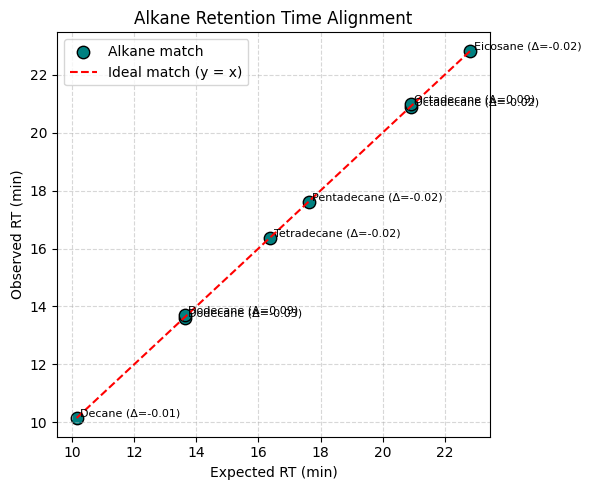

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import  match_alkanes, plot_alkane_alignment

#  Match alkanes
alkane_matches = match_alkanes(cleaned_qc, rt_tolerance=0.1, mz_tolerance=0.5)

#  Plot retention time alignment
plot_alkane_alignment(alkane_matches)





We saw that the closest  peak with retention time of octane, has m/z= 43 so we take it to consideration for further analysis

# Merge QC GC-MS Data with Master Metadata and Filter for QC Samples to have injection order for further analysis

In [ ]:

import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import merge_qc_with_master
import inspect
print(inspect.getsource(datapreparation_module.merge_qc_with_master))


# Extract config for biorep2
qc_merge_cfg = config["biorep2"]["qc_merge"]

# Run Merge using Config Paths

df_qc = merge_qc_with_master(
    file_master=qc_merge_cfg["master_path"],
    file_qc=qc_merge_cfg["qc_path"]
)


# Display result info

print("\n Merged QC–Master data saved successfully for biorep2:")
print(f" Output file: {qc_merge_cfg['output_path']}")
print(f" Final merged shape: {df_qc.shape}")

display(df_qc.head())

def merge_qc_with_master(file_master, file_qc):
    """
    Merges cleaned QC GC-MS data with the experiment master table metadata.

    Steps:
    1. Reads the master table (CSV) and cleaned QC file (CSV).
    2. Converts the wide QC table into long (tidy) format using melt().
    3. Extracts sample filenames from column headers.
    4. Merges with metadata (Sample, Day, Injection order).
    5. Filters only QC samples (Sample names starting with 'QC').

    Parameters
    ----------
    file_master : str
        Path to the master metadata table CSV file.
    file_qc : str
        Path to the cleaned QC dataset CSV file.

    Returns
    -------
    pd.DataFrame
        A merged DataFrame containing QC samples with associated metadata.
    """

    # Load both input files
    master_table = pd.read_csv(file_master)
    cleaned_qc = pd.read_csv(file_qc)

    # Reshape from wide to long format
    df_long_qc = cleaned_qc.melt(
        id_vars=["Peak", "tR_best", "m/z"],
        var_nam

,Peak,tR_best,m/z,SampleCol,Intensity,Filename,Sample,Day,Injection_order
0,1,1.8445,262,s1 S96_QC1_B2_D11_T1,1414,S96_QC1_B2_D11_T1,QC1,11,312
1,2,1.9540,44,s1 S96_QC1_B2_D11_T1,489320,S96_QC1_B2_D11_T1,QC1,11,312
2,3,1.9820,61,s1 S96_QC1_B2_D11_T1,31346,S96_QC1_B2_D11_T1,QC1,11,312
3,4,2.0100,58,s1 S96_QC1_B2_D11_T1,18028,S96_QC1_B2_D11_T1,QC1,11,312
4,5,2.0285,40,s1 S96_QC1_B2_D11_T1,108907,S96_QC1_B2_D11_T1,QC1,11,312


# Check QC1–QC4 linearity per day

In [7]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import evaluate_qc_linearity
from sklearn.linear_model import LinearRegression
results_df = evaluate_qc_linearity(alkane_matches, df_qc)
display(results_df)


 Evaluated QC linearity for 80 (Compound, Day) combinations.


,Compound,Peak,Day,tR_best,m/z,R2
0,Decane,174.0,11,10.140,57,0.901052
1,Decane,174.0,12,10.140,57,0.917647
2,Decane,174.0,13,10.140,57,0.964263
3,Decane,174.0,14,10.140,57,0.840677
4,Decane,174.0,15,10.140,57,0.961078
...,...,...,...,...,...,...
75,Tetradecane,359.0,16,16.369,57,0.976015
76,Tetradecane,359.0,17,16.369,57,0.885269
77,Tetradecane,359.0,18,16.369,57,0.946746
78,Tetradecane,359.0,19,16.369,57,0.942937


 Alkanes were detected in QC samples, and their intensities show strong linear relationships with QC order, confirming their use as internal standards for quality control.

# Dashboard for daily QC Linear Trend Analysis and Identification of Stable Peaks

In [8]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import launch_qc_linearity_dashboard
# Keep only the best peak per compound per day
best_results = (
    results_df.sort_values(by="R2", ascending=False)
    .drop_duplicates(subset=["Compound", "Day"])
)
launch_qc_linearity_dashboard(df_qc, best_results)




 Launching QC Linear Trend Dashboard at http://127.0.0.1:8040


it’s a dashboard to visualize QC linear trends per day with regression fits.

# Filter Stable QC Peaks by R² Linearity Threshold

In [ ]:

import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import filter_stable_peaks_by_r2

stable_peaks = filter_stable_peaks_by_r2(results_df, r2_threshold=0.9)

print("\nStable peak IDs:", stable_peaks["Peak"].unique())


 Found 7 unique stable peaks across 9 days (R² ≥ 0.9)
    Day     Compound   Peak  tR_best  m/z        R2
0    11       Decane  174.0  10.1400   57  0.901052
10   11     Dodecane  275.0  13.6000   57  0.933884
30   11     Eicosane  571.0  22.8045   57  0.940483
40   11   Octadecane  503.0  20.8835   57  0.950996
60   11  Pentadecane  398.0  17.6005   57  0.949375
70   11  Tetradecane  359.0  16.3690   57  0.933997
1    12       Decane  174.0  10.1400   57  0.917647
41   12   Octadecane  503.0  20.8835   57  0.912870
61   12  Pentadecane  398.0  17.6005   57  0.906258
2    13       Decane  174.0  10.1400   57  0.964263
12   13     Dodecane  275.0  13.6000   57  0.936572
32   13     Eicosane  571.0  22.8045   57  0.903860
62   13  Pentadecane  398.0  17.6005   57  0.954476
72   13  Tetradecane  359.0  16.3690   57  0.964165
33   14     Eicosane  571.0  22.8045   57  0.902576
63   14  Pentadecane  398.0  17.6005   57  0.920244
73   14  Tetradecane  359.0  16.3690   57  0.915977
4    15   

# Perform One-Way ANOVA to Assess Day-to-Day QC Intensity Stability

In [10]:

import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import perform_anova_on_qc_peaks

anova_df = perform_anova_on_qc_peaks(df_qc, results_df)

display(anova_df.head())


 ANOVA completed for 8 peaks across days.
Significant (p<0.05): 2 peaks


,Compound,Peak,tR_best,m/z,ANOVA_F,ANOVA_p
0,Decane,174,10.1400,57,3.046825,0.010368
1,Dodecane,275,13.6000,57,0.369845,0.940535
2,Dodecane,278,13.7130,57,6.691532,0.000033
3,Eicosane,571,22.8045,57,1.325071,0.265722
4,Octadecane,503,20.8835,57,0.806768,0.613548


ANOVA shows no, they do not differ across biological groups (they’re chemically stable references.

# Visualize QC Injection Stability Using LOESS Smoothing

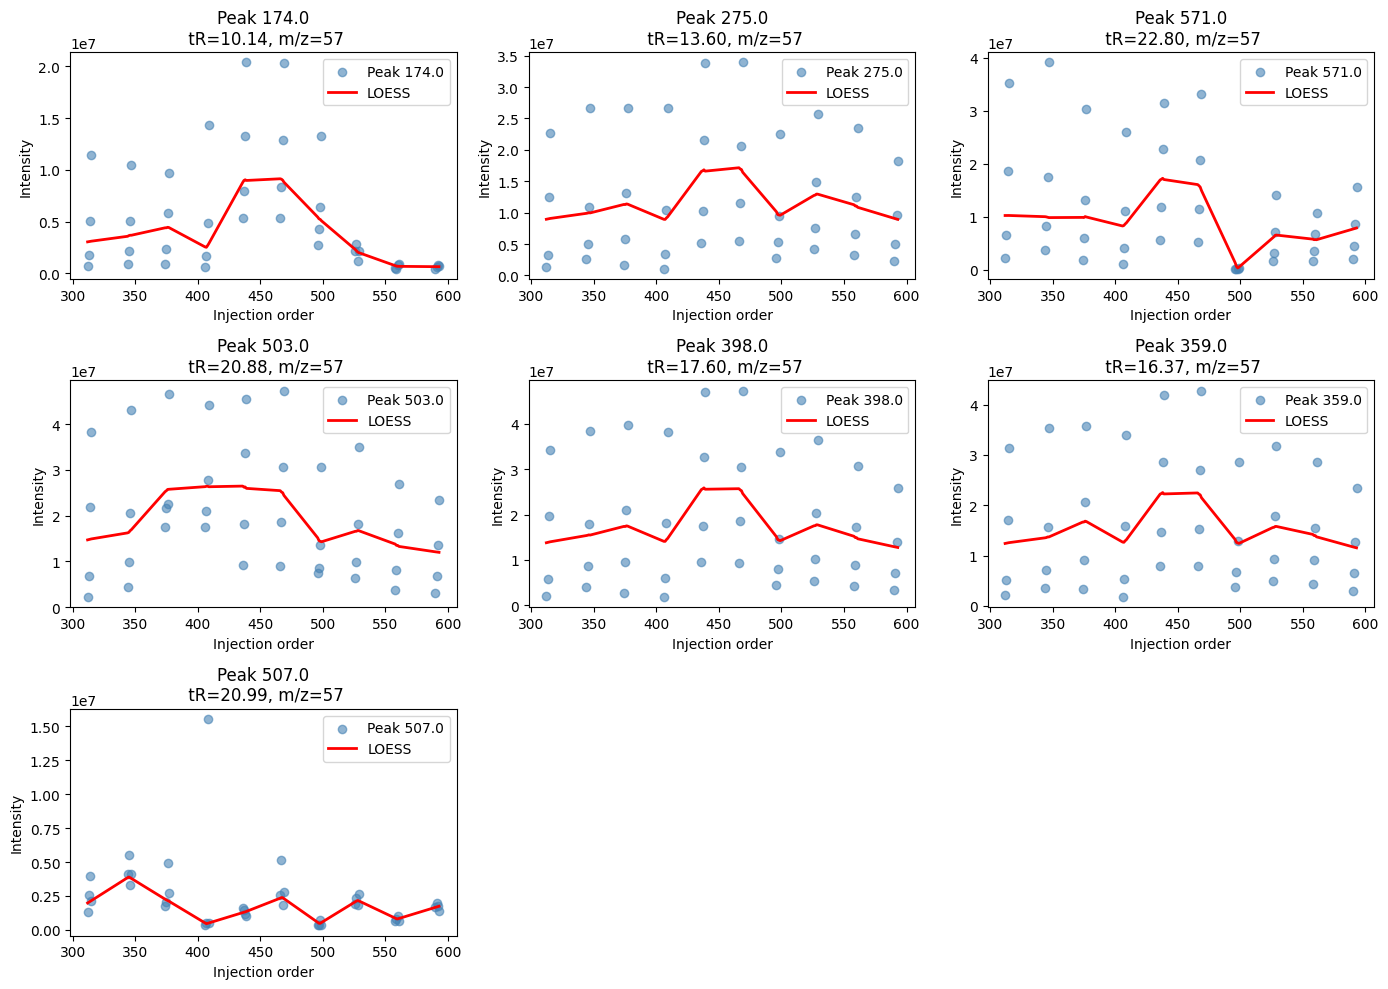

 Displayed LOESS trends for 7 stable peaks.


In [11]:


import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import plot_loess_trends_for_stable_peaks

plot_loess_trends_for_stable_peaks(df_qc, stable_peaks, max_plots=9, frac=0.3)



# Visualize QC Level Drift Across Injection Order for Stable Peaks by linear regression

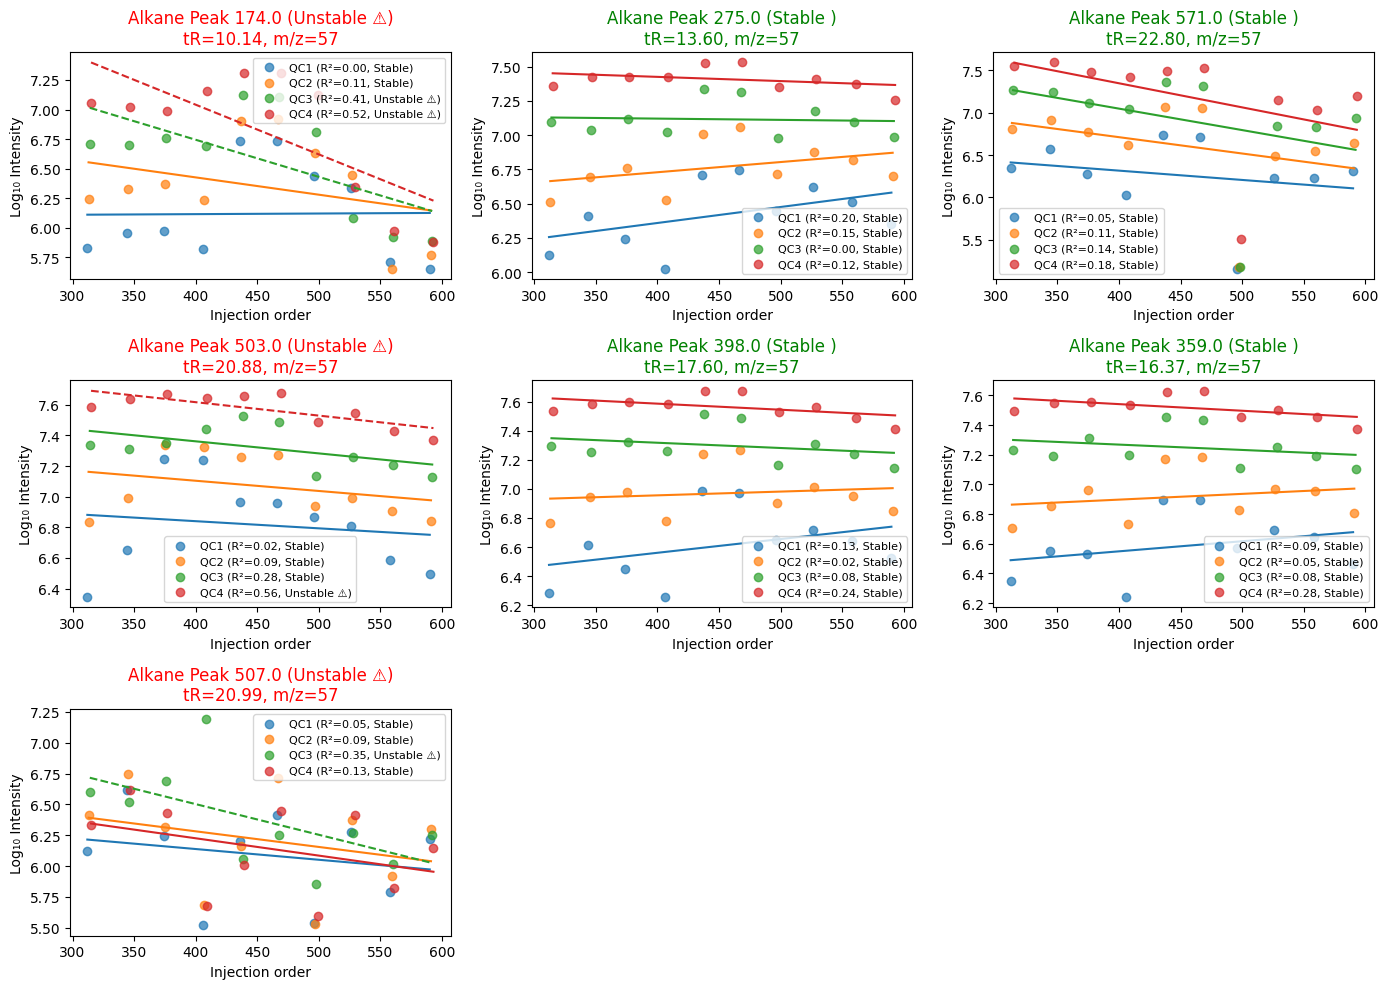

In [12]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import plot_alkane_stability_colored

stability_summary_colored = plot_alkane_stability_colored(
    df_qc=df_qc,
    stable_peaks=stable_peaks,
    r2_threshold=0.3
)


# Optimization of LOESS Parameters for QC Drift Correction

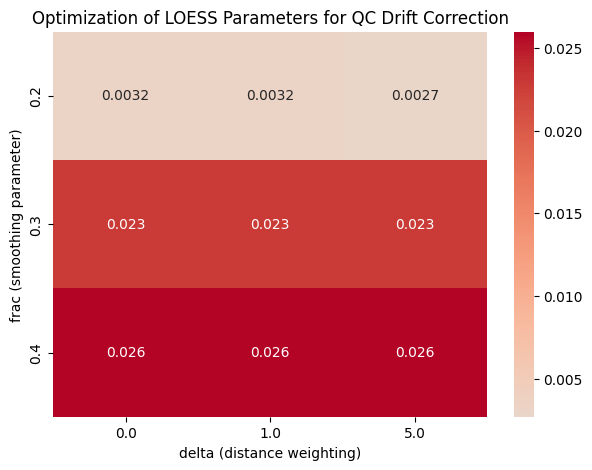

Best LOESS parameters for drift correction:
frac                0.400000
alpha               0.010000
delta               5.000000
mean_improvement    0.025964
Name: 20, dtype: float64


,frac,alpha,delta,mean_improvement
0,0.2,0.01,0.0,0.003207
1,0.2,0.01,1.0,0.003207
2,0.2,0.01,5.0,0.002722
3,0.2,0.05,0.0,0.003207
4,0.2,0.05,1.0,0.003207


In [13]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import  optimize_loess_drift_correction

# Call the LOESS optimization function
best_params, opt_df = optimize_loess_drift_correction(df_qc, stable_peaks)

# Print the best parameter combination
print("Best LOESS parameters for drift correction:")
print(best_params)

# Display the full optimization results
display(opt_df.head())


# Drift correction

 Loaded master table from: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/files/project file/GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv


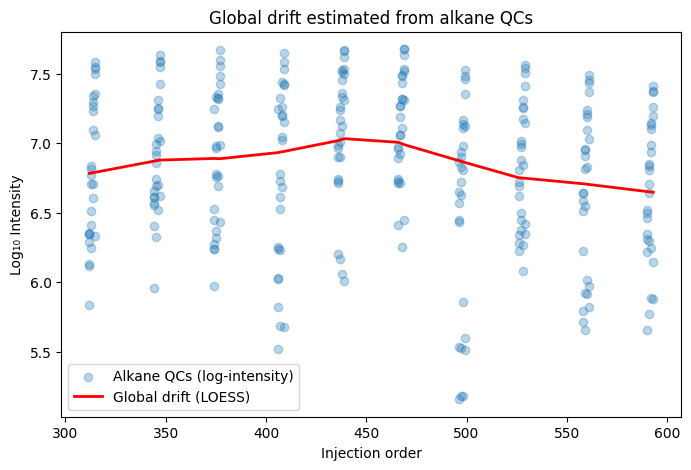

 Global QC R² before: 0.0046
 Global QC R² after : 0.0000


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\datapreparation_module.py:1003: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




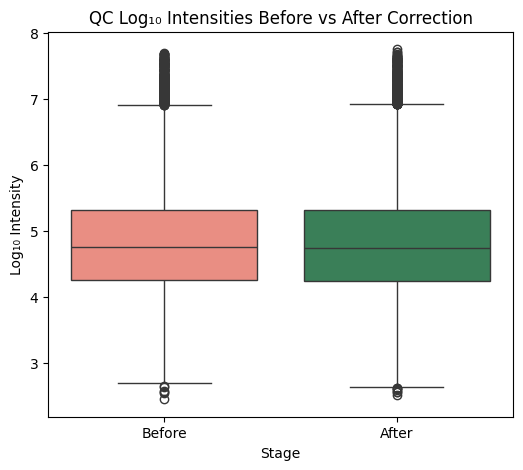

 Global sample variance before: 0.506022
 Global sample variance after : 0.502842


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\datapreparation_module.py:1026: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




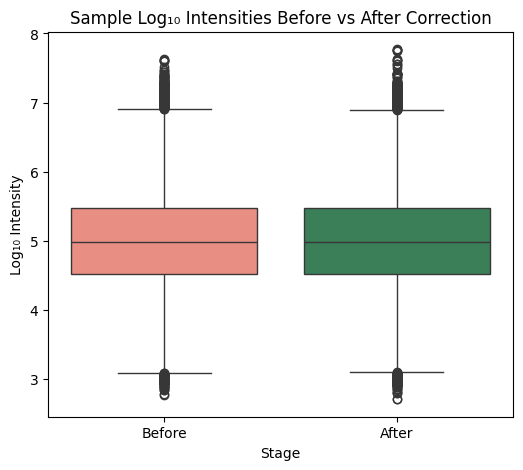

 Drift correction and global boxplot evaluation completed.


In [ ]:
import tempfile
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import apply_alkane_drift_correction_global

# Load the full config
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Extract only the biorep2 section
biorep2_config = config["biorep2"]

# Write biorep2 section to a temporary YAML file
temp_yaml = tempfile.NamedTemporaryFile(mode="w", delete=False, suffix=".yaml", encoding="utf-8")

yaml.safe_dump(biorep2_config, temp_yaml)
temp_yaml.close()

results = apply_alkane_drift_correction_global(
    df_qc=df_qc,
    selected_data=selected_data,
    stable_peaks=stable_peaks,
    config_path=temp_yaml.name,  
    loess_frac=0.4
)

# Extract corrected data
df_corrected = results["df_corrected"]


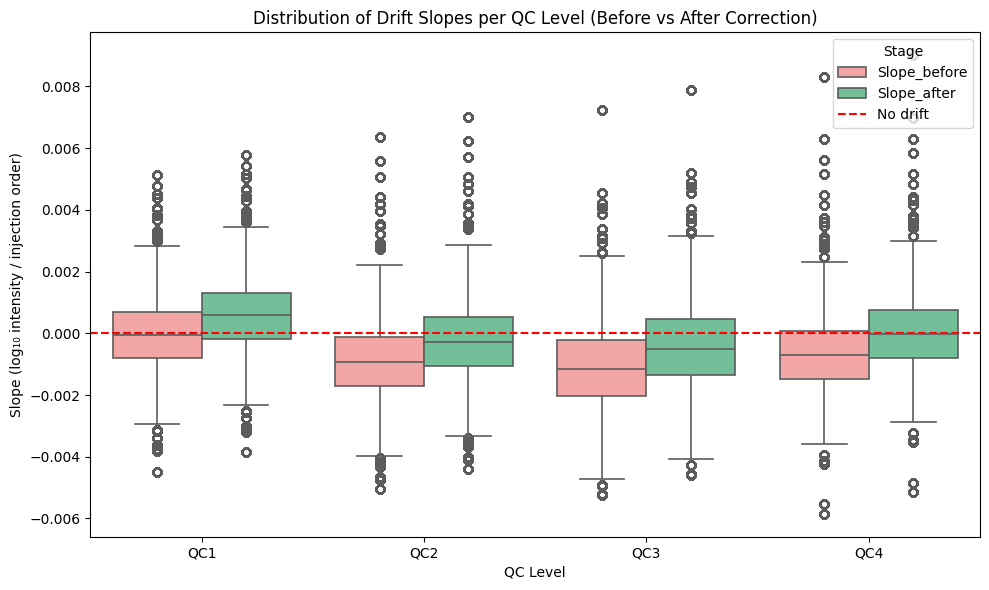


 Mean slope before correction: -0.0006305187007513733
 Mean slope after correction : 2.8284090389007537e-05

 Drift slope evaluation complete.


,QC,Slope_before,Slope_after
0,QC1,0.000812,0.001440
1,QC1,0.000812,0.001150
2,QC1,0.000812,-0.000928
3,QC1,0.000812,0.001396
4,QC1,0.000812,-0.000379


In [15]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import plot_qc_drift_slopes

slopes_df = plot_qc_drift_slopes(df_qc=df_qc, df_corrected=df_corrected)
display(slopes_df.head())


# Rank QCs on corrected data

QC reproducibility ranking (best → worst):
  Sample  Median_intensity        CV  Completeness     Score  Rank
0    QC2      58345.023080  3.882402           1.0  2.826639     1
1    QC3      59476.908943  4.093952           1.0  2.685269     2
2    QC1      47875.667870  4.362644           1.0  2.470149     3
3    QC4      57542.474753  5.032591           1.0  2.177863     4


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\datapreparation_module.py:1295: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




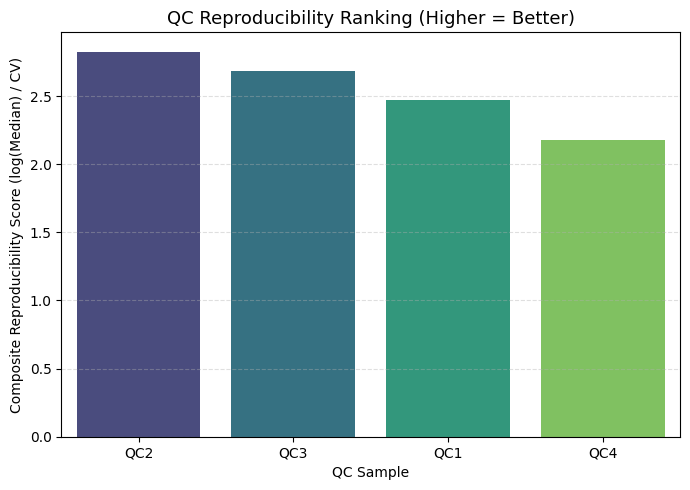

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import evaluate_qc_reproducibility, plot_qc_reproducibility
#Compute QC reproducibility
qc_stats = evaluate_qc_reproducibility(df_corrected)

# Plot ranking
plot_qc_reproducibility(qc_stats)



# Normalization by QC2

In [17]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import normalize_samples

normalized_samples = normalize_samples(df_corrected, qc_label="QC2")

# Preview result
print(normalized_samples[["Peak", "Intensity_corrected", "QC2_median",
                          "Ratio_normalized", "Log10_normalized"]].head())


 Samples normalized relative to QC2.
Number of samples normalized: 60420
Number of peaks referenced: 593
   Peak  Intensity_corrected   QC2_median  Ratio_normalized  Log10_normalized
0     1         28137.573614  5141.675476          5.472452          0.811069
1     1         23588.428148  5141.675476          4.587693          0.747233
2     1         30044.552623  5141.675476          5.843339          0.835268
3     1         26199.767422  5141.675476          5.095570          0.785014
4     1         27842.674875  5141.675476          5.415098          0.807203


In [18]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import  extract_and_export_samples

samples_filtered = extract_and_export_samples(normalized_samples, output_path="samples_filtered.csv")

# Preview result
print(samples_filtered.head())



 Filtered samples saved to: samples_filtered.csv
Number of rows exported: 60420
           Filename                          Sample  Peak   Variety  tR_best  \
0  S96_51_B2_D11_T1     NLD;MET;96;64;2024;51;HANSA     1     HANSA    1.901   
1   S96_5_B2_D11_T1    NLD;MET;96;64;2024;5;ALTURAS     1   ALTURAS    1.901   
2   S96_9_B2_D11_T1       NLD;MET;96;64;2024;9;ANTI     1      ANTI    1.901   
3  S96_80_B2_D11_T1    NLD;MET;96;64;2024;80;SABABA     1    SABABA    1.901   
4  S96_88_B2_D11_T1  NLD;MET;96;64;2024;88;SYMFONIA     1  SYMFONIA    1.901   

   m/z  Intensity_corrected  Ratio_normalized  Log10_normalized  
0   40         28137.573614          5.472452          0.811069  
1   40         23588.428148          4.587693          0.747233  
2   40         30044.552623          5.843339          0.835268  
3   40         26199.767422          5.095570          0.785014  
4   40         27842.674875          5.415098          0.807203  


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\datapreparation_module.py:1436: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




 Plot saved to normalization_effect.png

 Normalization Effect Summary
Variance before normalization : 0.502842
Variance after normalization  : 0.310585
Reduction in variance         : 38.23%
{'variance_before': np.float64(0.5028419014746284), 'variance_after': np.float64(0.31058458265163075), 'reduction_percent': np.float64(38.234148399166024)}


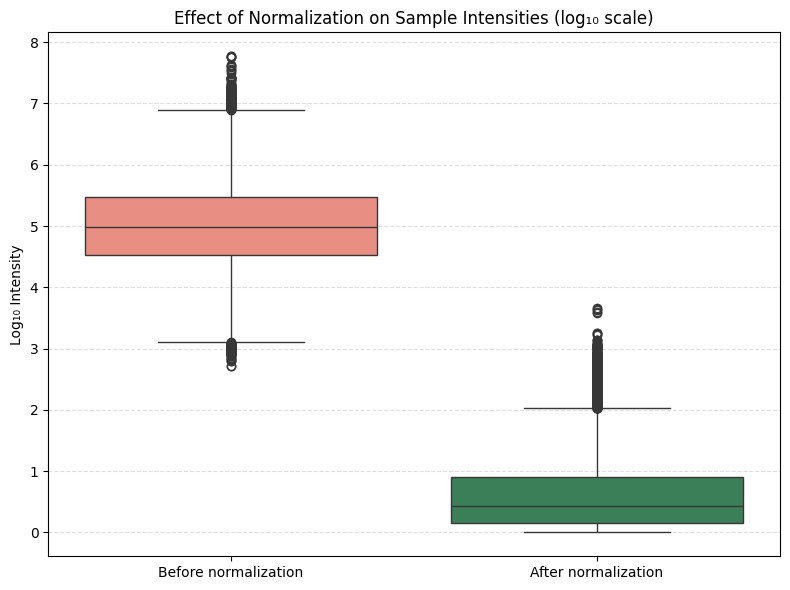

In [19]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import evaluate_normalization_effect

results = evaluate_normalization_effect(normalized_samples,
                                        output_path="normalization_effect.png")

print(results)


# Attaching Variety Information to Sample Metadata

In [20]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import attach_variety_info

samples_with_variety = attach_variety_info(normalized_samples)
print(samples_with_variety.head())


 Attached 'Variety' information for 94 varieties.
Total samples with assigned Variety: 60420
        #          Filename                          Sample  Block  Plot  \
0  1460.0  S96_51_B2_D11_T1     NLD;MET;96;64;2024;51;HANSA    1.0   1.0   
1  1461.0   S96_5_B2_D11_T1    NLD;MET;96;64;2024;5;ALTURAS    1.0   2.0   
2  1462.0   S96_9_B2_D11_T1       NLD;MET;96;64;2024;9;ANTI    1.0   3.0   
3  1463.0  S96_80_B2_D11_T1    NLD;MET;96;64;2024;80;SABABA    1.0   4.0   
4  1464.0  S96_88_B2_D11_T1  NLD;MET;96;64;2024;88;SYMFONIA    1.0   5.0   

   Sample_order  Sample_date  Rep  Day  Injection_order  ...  Peak  tR_best  \
0          95.0          NaN  2.0   11              318  ...     1    1.901   
1          96.0          NaN  2.0   11              319  ...     1    1.901   
2          97.0          NaN  2.0   11              320  ...     1    1.901   
3          98.0          NaN  2.0   11              321  ...     1    1.901   
4          99.0          NaN  2.0   11              322

# Unsupervised Multivariate Analysis of Sample Profiles Using PCA and HCA


# PCA

In [21]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import perform_pca_interactive_biplot

pca_results = perform_pca_interactive_biplot(samples_with_variety, feature_col="Log10_normalized", point_color="navy")


scores_df = pca_results["scores_df"]
loadings_df = pca_results["loadings_df"]



 Performing PCA (uniform color mode)...
 PCA completed. Explained variance: PC1 = 29.30%, PC2 = 13.67%


# HCA (Hierarchical Cluster Analysis)



 Performing Hierarchical Clustering...
 Clustering completed using 'ward' linkage with 5 clusters.
First few cluster assignments:
           Filename  Cluster    Variety
0  S96_10_B2_D20_T1        4    ARDECHE
1  S96_11_B2_D15_T1        1      ARGOS
2  S96_12_B2_D19_T1        4    ARIZONA
3  S96_13_B2_D14_T1        1   ATLANTIC
4  S96_14_B2_D15_T1        1     AVARNA
5  S96_15_B2_D12_T1        2    AVENGER
6  S96_16_B2_D13_T1        5     BARAKA
7  S96_17_B2_D16_T1        5     BERBER
8  S96_18_B2_D19_T1        4  BILDTSTAR
9  S96_19_B2_D19_T1        3     BINTJE


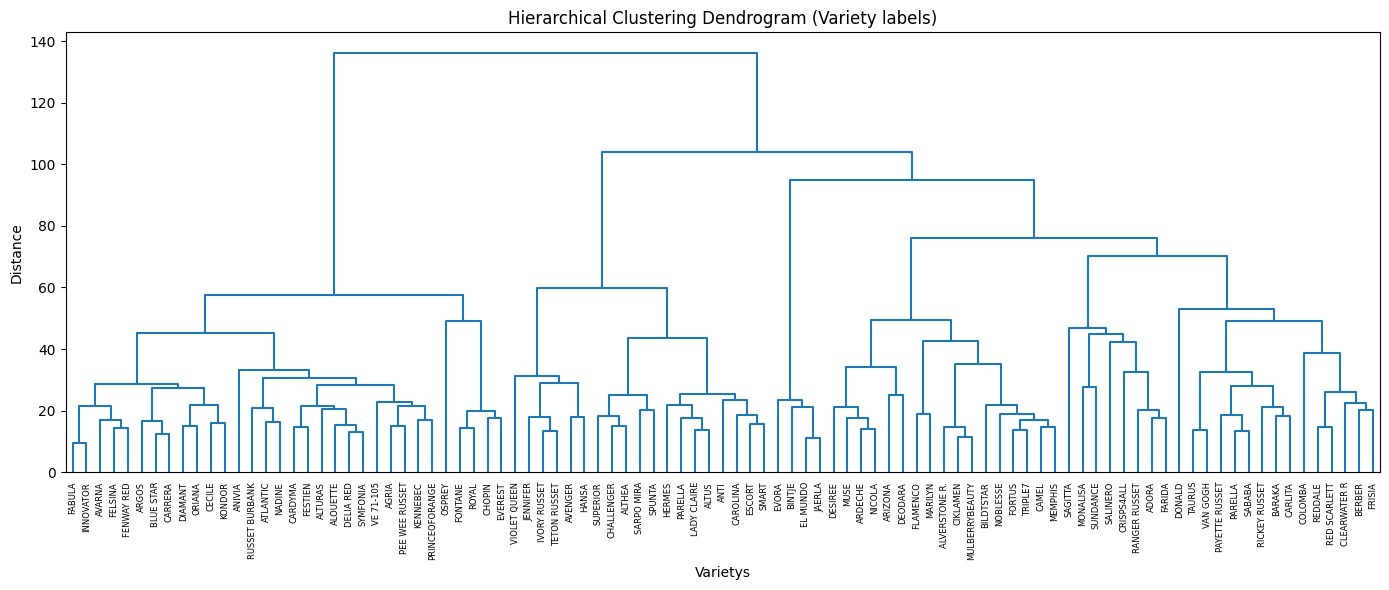

<Figure size 640x480 with 0 Axes>

In [22]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import perform_hierarchical_clustering

hca_results = perform_hierarchical_clustering(
    samples_with_variety,
    feature_col="Log10_normalized",
    method="ward",
    n_clusters=5,
    plot_labels="Variety"
)

Reveals blocks of peaks that vary together across groups of varieties

# Integration of PCA and Hierarchical Clustering for Sample Grouping Analysis


 Evaluating Hierarchical Clustering Across Multiple Metrics...
 Cophenetic correlation coefficient: 0.398

k=2: silhouette=0.121, calinski=18.3, davies=1.930
k=3: silhouette=0.138, calinski=16.2, davies=2.010
k=4: silhouette=0.159, calinski=15.6, davies=1.739
k=5: silhouette=0.150, calinski=14.5, davies=1.925
k=6: silhouette=0.158, calinski=13.7, davies=1.822
k=7: silhouette=0.153, calinski=12.8, davies=1.740
k=8: silhouette=0.153, calinski=12.2, davies=1.714
k=9: silhouette=0.153, calinski=11.7, davies=1.536


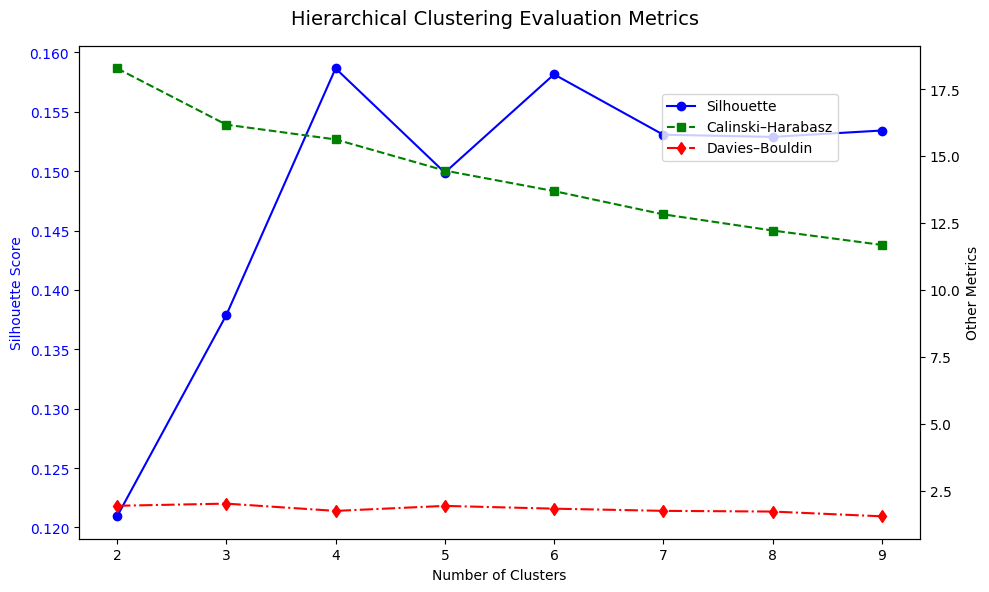


 Evaluation complete. Use Silhouette (↑), Calinski–Harabasz (↑), and Davies–Bouldin (↓) to choose optimal k.

 Summary of clustering metrics:


,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.120935,18.273075,1.929892
1,3,0.137893,16.169668,2.010475
2,4,0.158657,15.619006,1.738638
3,5,0.149885,14.454999,1.925455
4,6,0.158154,13.688595,1.822286
5,7,0.153071,12.819548,1.740329
6,8,0.152888,12.215920,1.714043
7,9,0.153425,11.678328,1.535845



 Optimal number of clusters (based on silhouette): 4

 Generating PCA plot with 2 hierarchical clusters...
 PCA cluster visualization ready.


In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import evaluate_hierarchical_clustering_full
from sklearn.preprocessing import StandardScaler
from datapreparation_module import plot_pca_clusters
# Convert samples × peaks matrix
X = samples_with_variety.pivot_table(
    index="Filename",
    columns="Peak",
    values="Log10_normalized",  
    aggfunc="mean"
).fillna(0)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


results = evaluate_hierarchical_clustering_full(
    samples_with_variety,
    feature_col="Log10_normalized",
    method="ward",
    cluster_range=(2, 10)
)

# Show results summary
print("\n Summary of clustering metrics:")
display(results["metrics"])

# Identify best silhouette score
best_k = results["metrics"].loc[results["metrics"]["Silhouette"].idxmax(), "Clusters"]
print(f"\n Optimal number of clusters (based on silhouette): {best_k}")

# Plot PCA clusters for the optimal number (k=2)
fig = plot_pca_clusters(pca_results, results, optimal_k=2)